In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)
from sklearn.neighbors import NearestNeighbors
import ahocorasick
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import geopandas as gpd
from shapely.geometry import Point
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

In [6]:
df_divar = pd.read_csv('Divar.csv')
df_city = pd.read_csv('iran_city_classification.csv')
df_divar = df_divar.merge(df_city ,  left_on='city_slug' , right_on='نام شهر' , how='left')
df_divar = df_divar.drop(columns='نام شهر')  

C:\Users\Toranj\AppData\Local\Temp\ipykernel_2728\1474697002.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_divar = pd.read_csv('Divar.csv')


In [8]:

def numeric_or_nan(series):
    return series.apply(lambda x: np.nan if isinstance(x, bool) else x).astype(float)

df_divar['transformable_price_n']  = numeric_or_nan(df_divar['transformable_price'])
df_divar['transformable_credit_n'] = numeric_or_nan(df_divar['transformable_credit'])
df_divar['transformable_rent_n']   = numeric_or_nan(df_divar['transformable_rent'])

is_daily = df_divar['cat2_slug'].eq('temporary-rent')
is_sale  = df_divar['cat2_slug'].str.endswith('-sell', na=False) | df_divar['cat3_slug'].isin(['plot-old', 'presell'])
is_rent  = df_divar['cat2_slug'].str.endswith('-rent', na=False) & ~is_daily

sale_price = df_divar['transformable_price_n'].fillna(df_divar['price_value'])


credit = df_divar['transformed_credit'].fillna(df_divar['transformable_credit_n']).fillna(df_divar['credit_value'])
rent = df_divar['transformed_rent'].fillna(df_divar['transformable_rent_n']).fillna(df_divar['rent_value'])
rent_price = rent * 600 + credit 
daily_price = df_divar[['rent_price_on_regular_days' , 'rent_price_on_special_days' , 'rent_price_at_weekends']].mean(axis=1)


df_divar['comparable_price'] = np.select(
    [is_sale, is_rent],
    [sale_price, rent_price],
    default=np.nan
)

rent_only = rent + credit / 12
df_divar['rent_credit'] = np.where(is_rent , rent_only , np.nan)
df_divar['rent_credit_tranformed'] = np.where(is_rent , rent_price , np.nan)
df_divar['daily_rent'] = np.where(is_daily , daily_price , np.nan)

df_divar['price_basis'] = np.select(
    [is_sale, is_rent, is_daily],
    ['sale', 'rent_credit', 'daily_rent'],
    default='unknown'
)

df_divar['comparable_price'] = pd.to_numeric(df_divar['comparable_price'], errors='coerce')



In [4]:
print(
    df_divar[
        [
            'transformed_credit',
            'transformable_credit_n',
            'credit_value',
            'transformed_rent',
            'transformable_rent_n',
            'rent_value'
        ]
    ].nunique()
)

transformed_credit         503
transformable_credit_n    1420
credit_value              1421
transformed_rent           589
transformable_rent_n      1311
rent_value                1311
dtype: int64


In [4]:
print(
    df_divar.groupby('price_basis')[
        [
            'price_value',
            'comparable_price',
            'rent_credit',
            'rent_credit_tranformed',
            'daily_rent'
        ]
    ].agg(['count', 'nunique', 'median', 'mean'])
)

            price_value                                     comparable_price  \
                  count nunique        median          mean            count   
price_basis                                                                    
daily_rent            5       5  4.800000e+05  7.182222e+05                0   
rent_credit          40      33  1.155556e+08  3.643187e+08           351182   
sale             568295   12941  2.840000e+09  1.736676e+10           568295   
unknown               6       6  1.055556e+10  1.340185e+10                0   

                                                rent_credit          \
            nunique        median          mean       count nunique   
price_basis                                                           
daily_rent        0           NaN           NaN       29903       1   
rent_credit    8090  3.200000e+09  2.465467e+13      353125       1   
sale          12941  2.840000e+09  1.736676e+10      613350       1   
unknown      

In [9]:

known = df_divar[df_divar['neighborhood_slug'].notna() &  df_divar['location_latitude'].notna() & df_divar['location_longitude'].notna()].copy()
missing = df_divar[df_divar['neighborhood_slug'].isna() & df_divar['location_latitude'].notna() & df_divar['location_longitude'].notna()].copy()

cord_known = known[['location_latitude', 'location_longitude']]
cord_missing = missing[['location_latitude', 'location_longitude']]

near_neighbors = NearestNeighbors(n_neighbors=1)
near_neighbors.fit(cord_known)

distances, indices = near_neighbors.kneighbors(cord_missing)

df_divar.loc[missing.index, 'neighborhood_slug'] = known.iloc[indices.flatten()]['neighborhood_slug'].values

In [10]:
df_divar['neighborhood_slug'] = df_divar['neighborhood_slug'].fillna('unknown')

df_divar['location_latitude'] = df_divar['location_latitude'].fillna(df_divar.groupby('city_slug')['location_latitude'].transform('mean'))
df_divar['location_longitude'] = df_divar['location_longitude'].fillna(df_divar.groupby('city_slug')['location_longitude'].transform('mean'))

In [11]:
numeric_cols = [
    'land_size',
    'building_size',
    'floor',
    'total_floors_count',
    'unit_per_floor'
]

for col in numeric_cols:

    df_divar[col] = pd.to_numeric(df_divar[col],errors='coerce')

    city_median = df_divar.groupby('city_slug')[col].transform('median')
    df_divar[col] = df_divar[col].fillna(city_median)

    df_divar[col] = df_divar[col].fillna(df_divar[col].median())

In [12]:
numeric_cols_1 = [
    'rooms_count', 
    'construction_year'
]


rooms_map = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5
}

df_divar['rooms_count'] = df_divar['rooms_count'].map(rooms_map)


persian_digits = str.maketrans(
    '۰۱۲۳۴۵۶۷۸۹',
    '0123456789'
)

df_divar['construction_year'] = df_divar['construction_year'].astype('string').str.translate(persian_digits)
df_divar['construction_year'] = df_divar['construction_year'].replace('قبل از 1370' , '1369')
df_divar['construction_year'] = pd.to_numeric(df_divar['construction_year'],errors='coerce')


for col in numeric_cols_1:
    df_divar[col] = df_divar[col].astype(float)

for col in numeric_cols_1:
    city_median = df_divar.groupby('city_slug')[col].transform('median')
    df_divar[col] = df_divar[col].fillna(city_median)

    df_divar[col] = df_divar[col].fillna(df_divar[col].median())

In [13]:
categorical_cols = [
    'deed_type',
    'building_direction',
    'has_warm_water_provider',
    'has_heating_system',
    'has_cooling_system',
    'has_restroom'
]

for col in categorical_cols:

    city_mode = df_divar.groupby('city_slug')[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    df_divar[col] = df_divar[col].fillna(city_mode)

    df_divar[col] = df_divar[col].fillna(df_divar[col].mode().iloc[0])

In [14]:
binary_cols = [
    'has_business_deed',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking',
    'is_rebuilt',
    'has_water',
    'has_electricity',
    'has_gas',
    'has_security_guard',
    'has_barbecue',
    'has_pool',
    'has_jacuzzi',
    'has_sauna'
]

for col in binary_cols:
    df_divar[col] = df_divar[col].replace({
            'true': True,
            'True': True,
            'false': False,
            'False': False,
            'unselect': np.nan
        })


for col in binary_cols:

    group_mode = df_divar.groupby(['city_slug'])[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    df_divar[col] = df_divar[col].fillna(group_mode)

    df_divar[col] = df_divar[col].fillna(df_divar[col].mode().iloc[0])

In [15]:
df_divar['floor_material'] = df_divar['floor_material'].replace('unselect' , np.nan)

group_mode = df_divar.groupby(['city_slug'])['floor_material'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
df_divar['floor_material'] = df_divar['floor_material'].fillna(group_mode)

df_divar['floor_material'] = df_divar['floor_material'].fillna(df_divar['floor_material'].mode().iloc[0])

In [16]:
weights = {
    'has_business_deed': 1,
    'has_balcony': 1,
    'has_elevator': 2,
    'has_warehouse': 2,
    'has_parking': 3,
    'is_rebuilt': 2,
    'has_water': 1,
    'has_electricity': 1,
    'has_gas': 1,
    'has_security_guard': 2,
    'has_barbecue': 1,
    'has_pool': 3,
    'has_jacuzzi': 3,
    'has_sauna': 3
}

df_divar['amenity_score'] = sum(df_divar[col] * weight for col , weight in weights.items())

In [17]:
df_divar = df_divar.drop(columns=binary_cols)

In [18]:
drop_list = [
    'created_at_month',
    'user_type',
    'description',
    'title',
    'rent_to_single',
    'building_direction',
    'property_type',
    'regular_person_capacity',
    'extra_person_capacity',
    'cost_per_extra_person',
    'rent_price_on_regular_days',
    'rent_price_on_special_days',
    'rent_price_at_weekends',
    'location_radius',
    'دسته‌بندی',
    'Unnamed: 0'
]

df_divar = df_divar.drop(columns=drop_list)

In [19]:

countries = gpd.read_file("map/ne_10m_admin_0_countries.shp")
iran = countries[countries["NAME"] == "Iran"]

geometry = [Point(lon, lat) for lon, lat in zip(df_divar["location_longitude"], df_divar["location_latitude"])]
gdf = gpd.GeoDataFrame(df_divar , geometry=geometry , crs="EPSG:4326")
df_divar = gdf[gdf.geometry.within(iran.geometry.iloc[0])].copy()

In [20]:
d_comp_price= ['rent_mode', 'rent_value', 'rent_type', 'price_mode', 'price_value', 'credit_mode',
       'credit_value', 'rent_credit_transform', 'transformable_price',
       'transformable_credit', 'transformed_credit', 'transformable_rent',
       'transformed_rent', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n'
]

df_comp_price = df_divar.drop(columns=d_comp_price).copy()

In [21]:
d_rent_price = [ 'rent_type', 'price_mode', 'price_value', 'credit_mode', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n', 'comparable_price']

df_rent_price = df_divar[df_divar['price_basis'] == 'rent_credit'].copy()
df_rent_price = df_rent_price.drop(columns=d_rent_price)

In [22]:
d_sale_price= ['rent_mode', 'rent_value', 'rent_type', 'price_mode', 'credit_mode',
       'credit_value', 'rent_credit_transform', 'transformable_price',
       'transformable_credit', 'transformed_credit', 'transformable_rent',
       'transformed_rent', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n'
]

df_sale_price = df_divar[df_divar['price_basis'] == 'sale'].copy()
df_sale_price = df_sale_price.drop(columns=d_sale_price)

In [23]:
d_rent_price = [ 'rent_type', 'price_mode', 'price_value', 'credit_mode', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n', 'comparable_price']

df_daily_price = df_divar[df_divar['price_basis'] == 'daily_rent'].copy()
df_daily_price = df_daily_price.drop(columns=d_rent_price)

In [24]:
def plot_cluster(sl_df , title , features , k , niter , wcss_en , plot_en , silhou_en , price_base):
    

    
    df_cluster = sl_df[features].copy()
    

    Q1 = df_cluster[price_base].quantile(0.25)
    Q3 = df_cluster[price_base].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cluster = df_cluster[(df_cluster[price_base] >= lower_bound) & (df_cluster[price_base] <= upper_bound)].copy()

    df_cluster = df_cluster.dropna(subset=features).copy()


    transformer = Transformer.from_crs('EPSG:4326' , 'EPSG:32639' , always_xy=True)
    df_cluster['utm_easting'], df_cluster['utm_northing'] = transformer.transform(df_cluster['location_longitude'].values , df_cluster['location_latitude'].values)


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_cluster[features])

    kmeans = KMeans(n_clusters=k , random_state=42 , n_init=niter)
    df_cluster['cluster'] = kmeans.fit_predict(X_scaled)
    
    
    if wcss_en == True :
        wcss = kmeans.inertia_
        return wcss

    if silhou_en == True and k != 1:
        silhou = silhouette_score(X_scaled, df_cluster['cluster'] , sample_size=10000 , random_state=42)
        return silhou            

    if plot_en == True :
        plt.figure(figsize=(16, 11))
        colors = plt.cm.tab20.colors

        for cluster in range(k):
            data = df_cluster[df_cluster['cluster'] == cluster]
            median_price = data[price_base].median()
            plt.scatter(data['utm_easting'] , data['utm_northing'] , s=3 , alpha= 0.3 , label=f'Cluster {cluster} | Median: {median_price:,.0f}' , rasterized=True , color=colors[cluster])



        centers = df_cluster.groupby('cluster')[['utm_easting', 'utm_northing']].mean()
        plt.scatter(centers['utm_easting'] , centers['utm_northing'] , marker='X' , s=20 , edgecolors='black' , linewidths=2 , label='Cluster Center' , zorder=10)



        for cluster, row in centers.iterrows():
            plt.annotate(f'Cluster {cluster}' , (row['utm_easting'] , row['utm_northing']) , xytext=(10, 10) , textcoords='offset points' , fontsize=8 , fontweight='bold' , bbox=dict(boxstyle='round,pad=0.2' , facecolor='white' , alpha=0.4))




        plt.xlabel('UTM Easting (meters)')
        plt.ylabel('UTM Northing (meters)')
        plt.title(f'K-Means Clustering of Properties (K = {k}) , {title} , {df_cluster.shape[0]}')
        plt.legend(bbox_to_anchor=(1.02, 1) , loc='upper left' , markerscale=3)
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()



        



# part 1

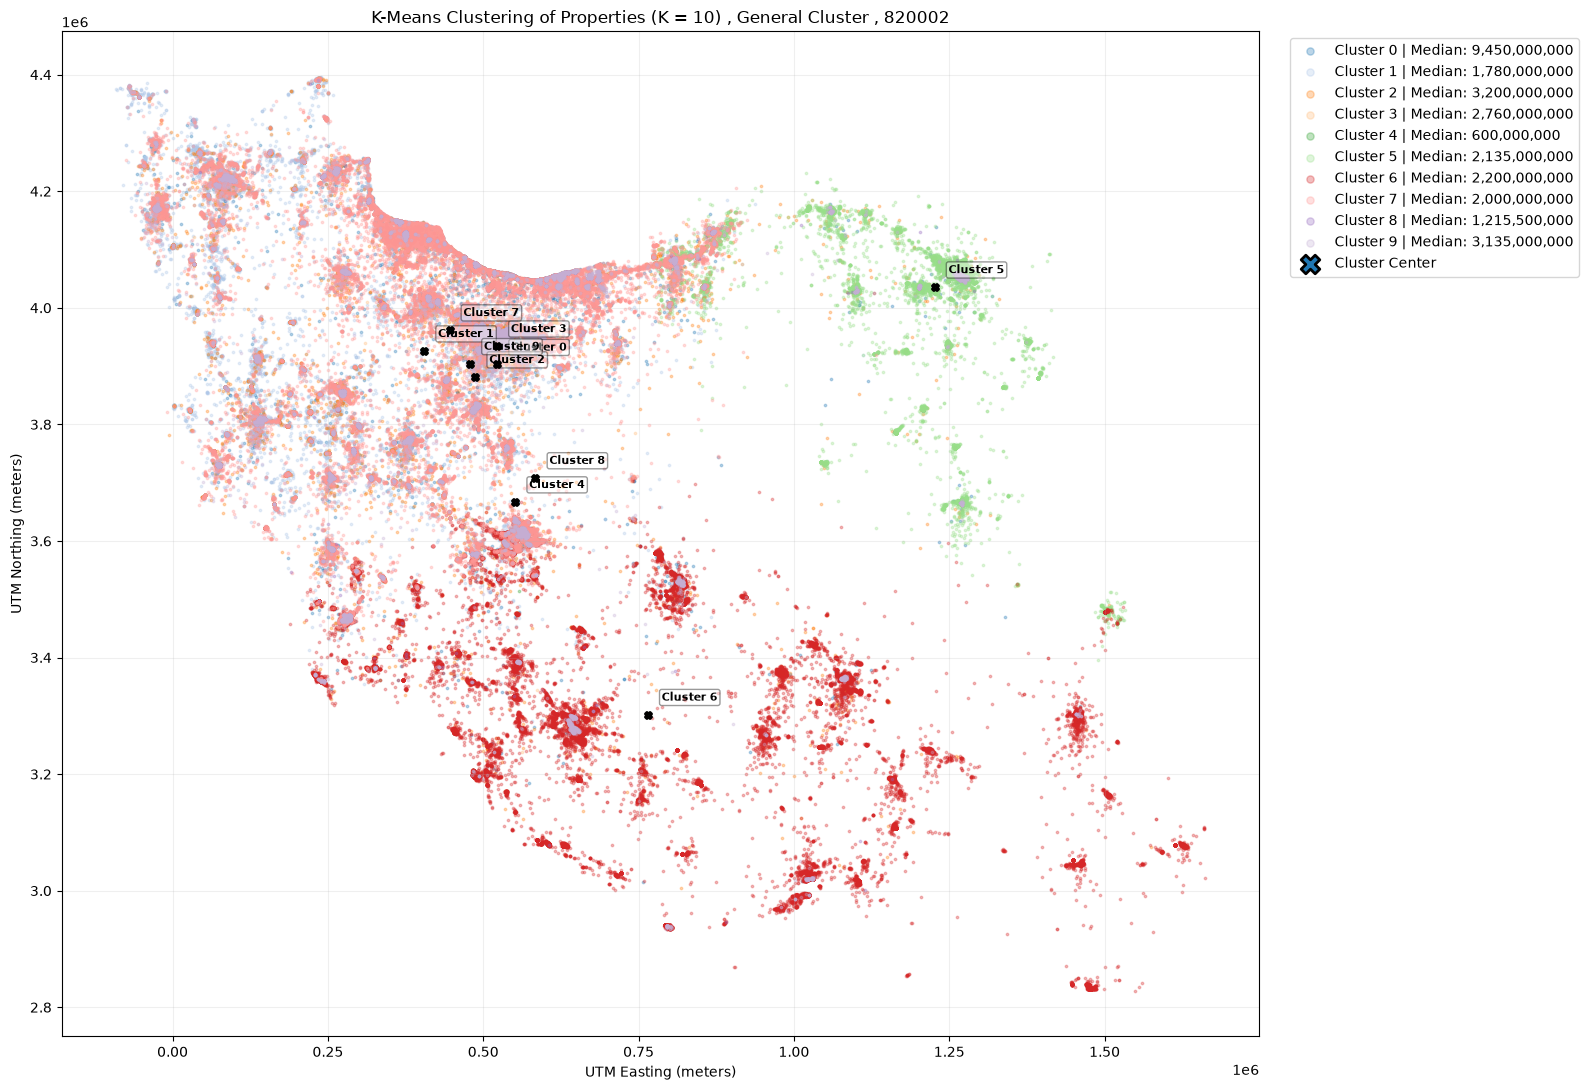

In [25]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'comparable_price'
]
plot_cluster(df_comp_price , 'General Cluster' , list_f , 10 , 10 , wcss_en = False , plot_en = True , silhou_en= False , price_base='comparable_price')

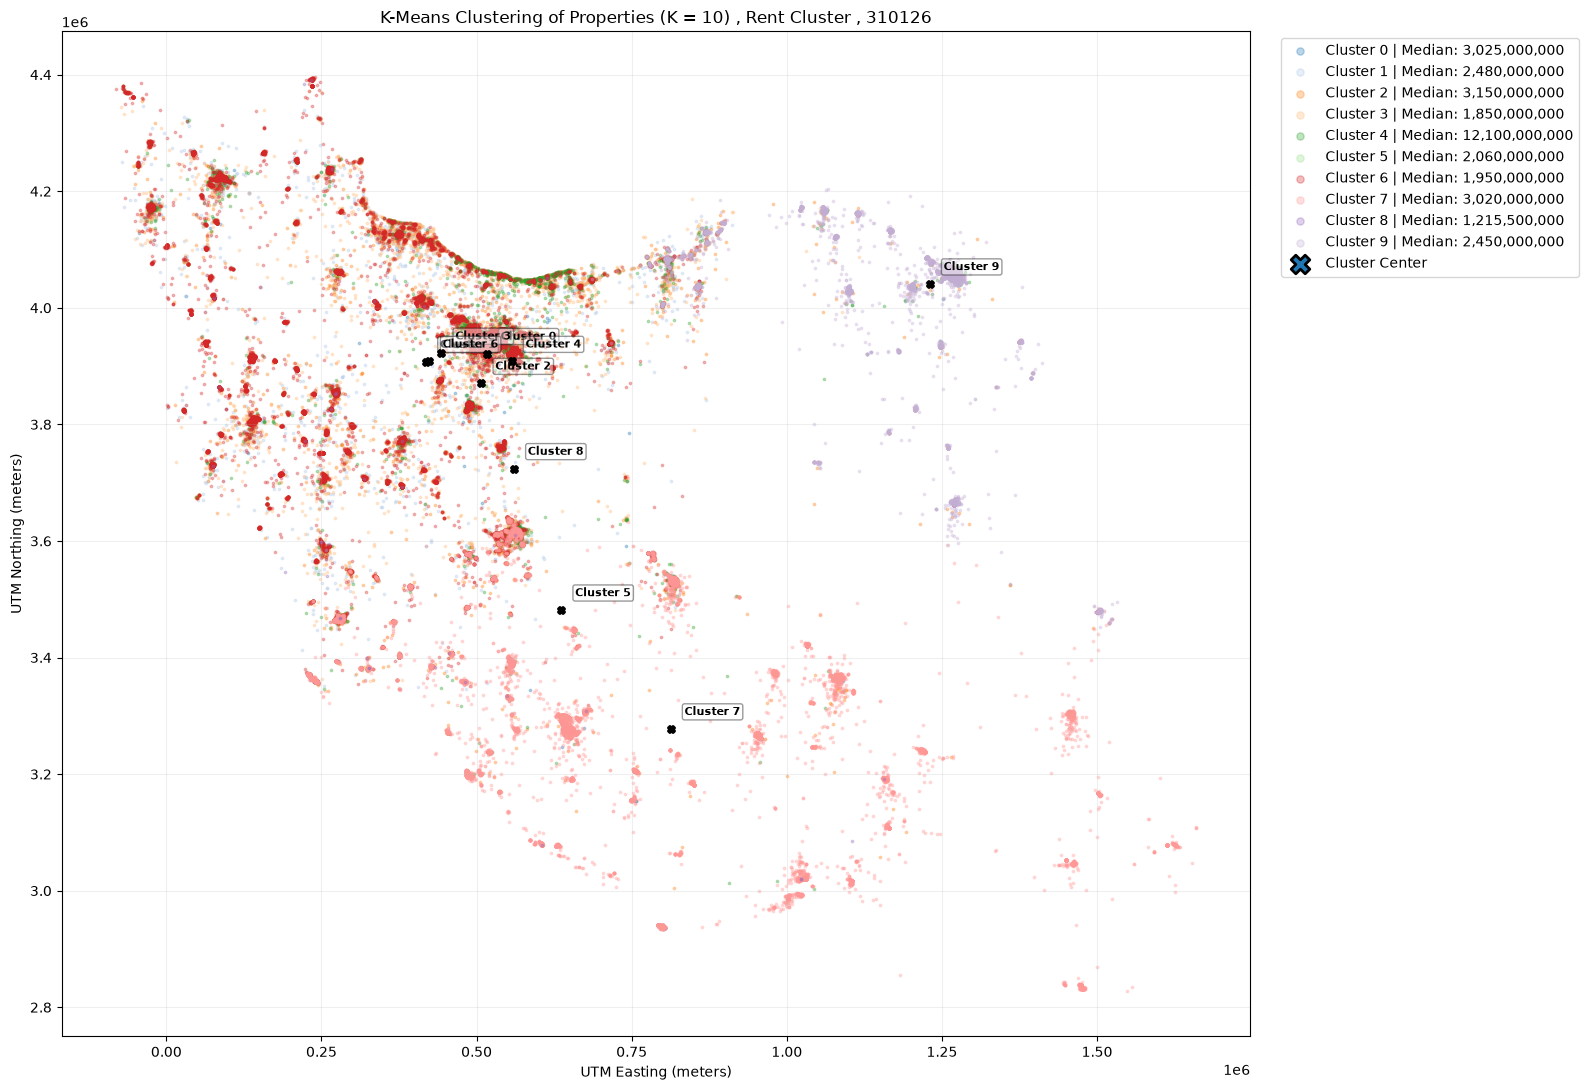

In [26]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'rent_credit_tranformed'
]
plot_cluster(df_rent_price , 'Rent Cluster' , list_f , 10 , 10, wcss_en = False , plot_en = True , silhou_en= False , price_base='rent_credit_tranformed')


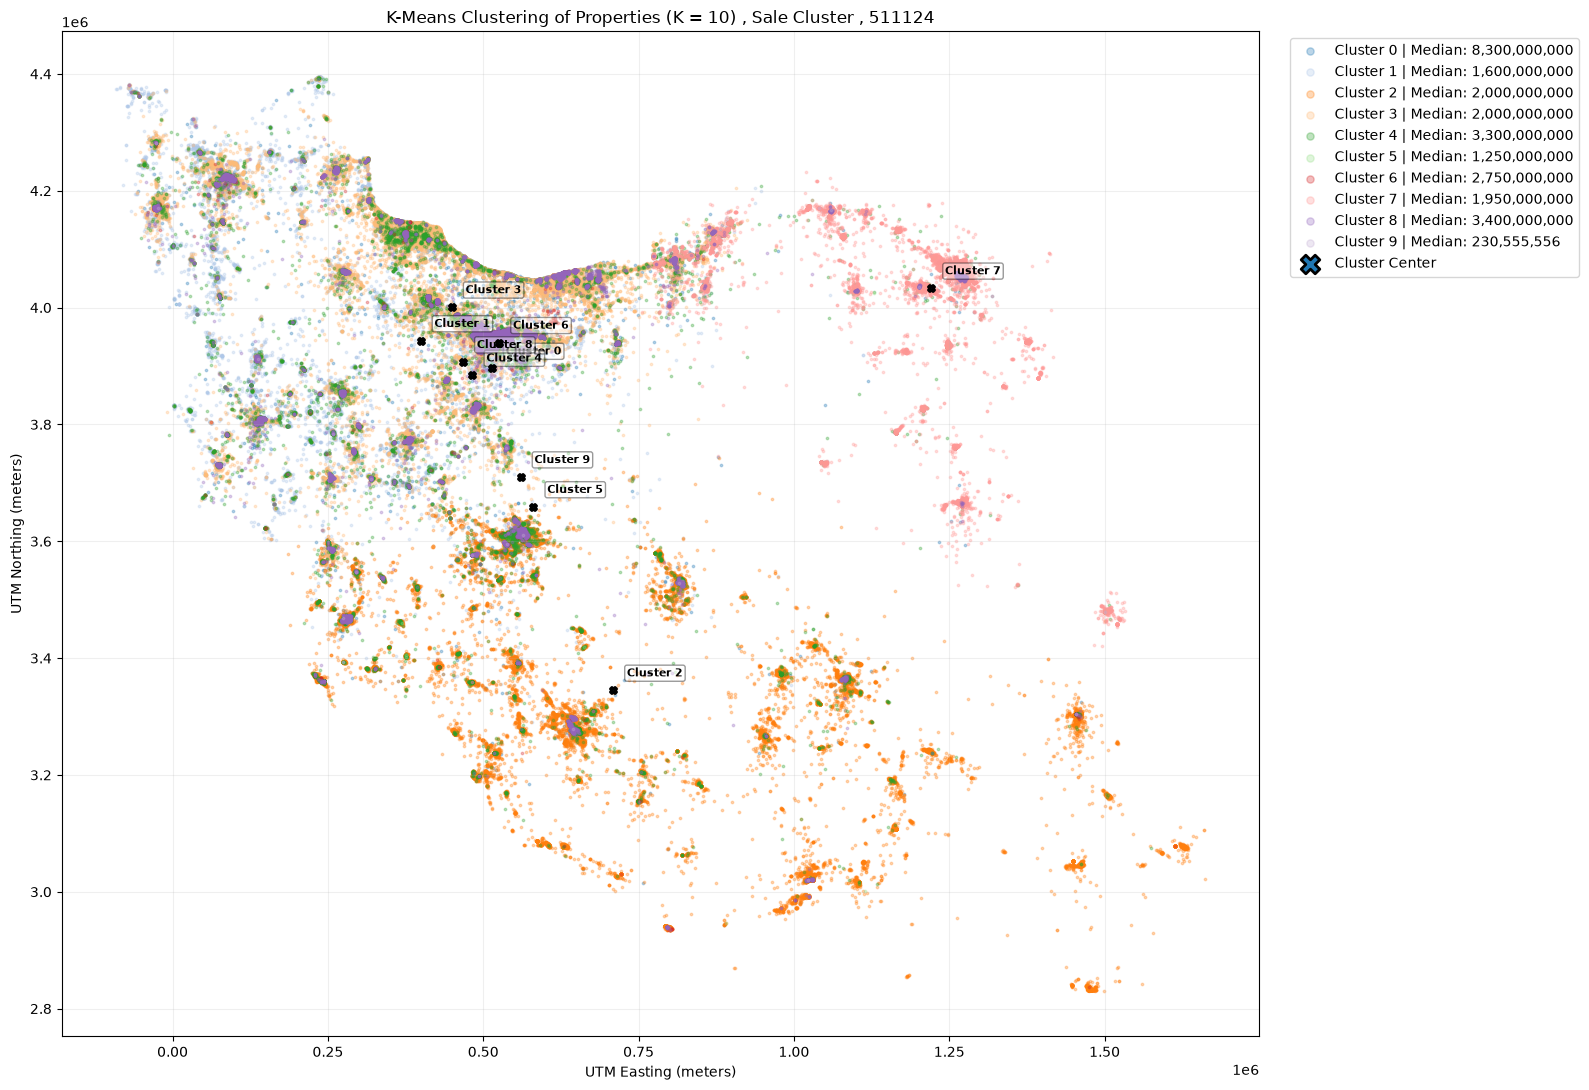

In [27]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'price_value'
]


plot_cluster(df_sale_price , 'Sale Cluster' , list_f , 10 , 10, wcss_en = False , plot_en = True , silhou_en= False , price_base='price_value')


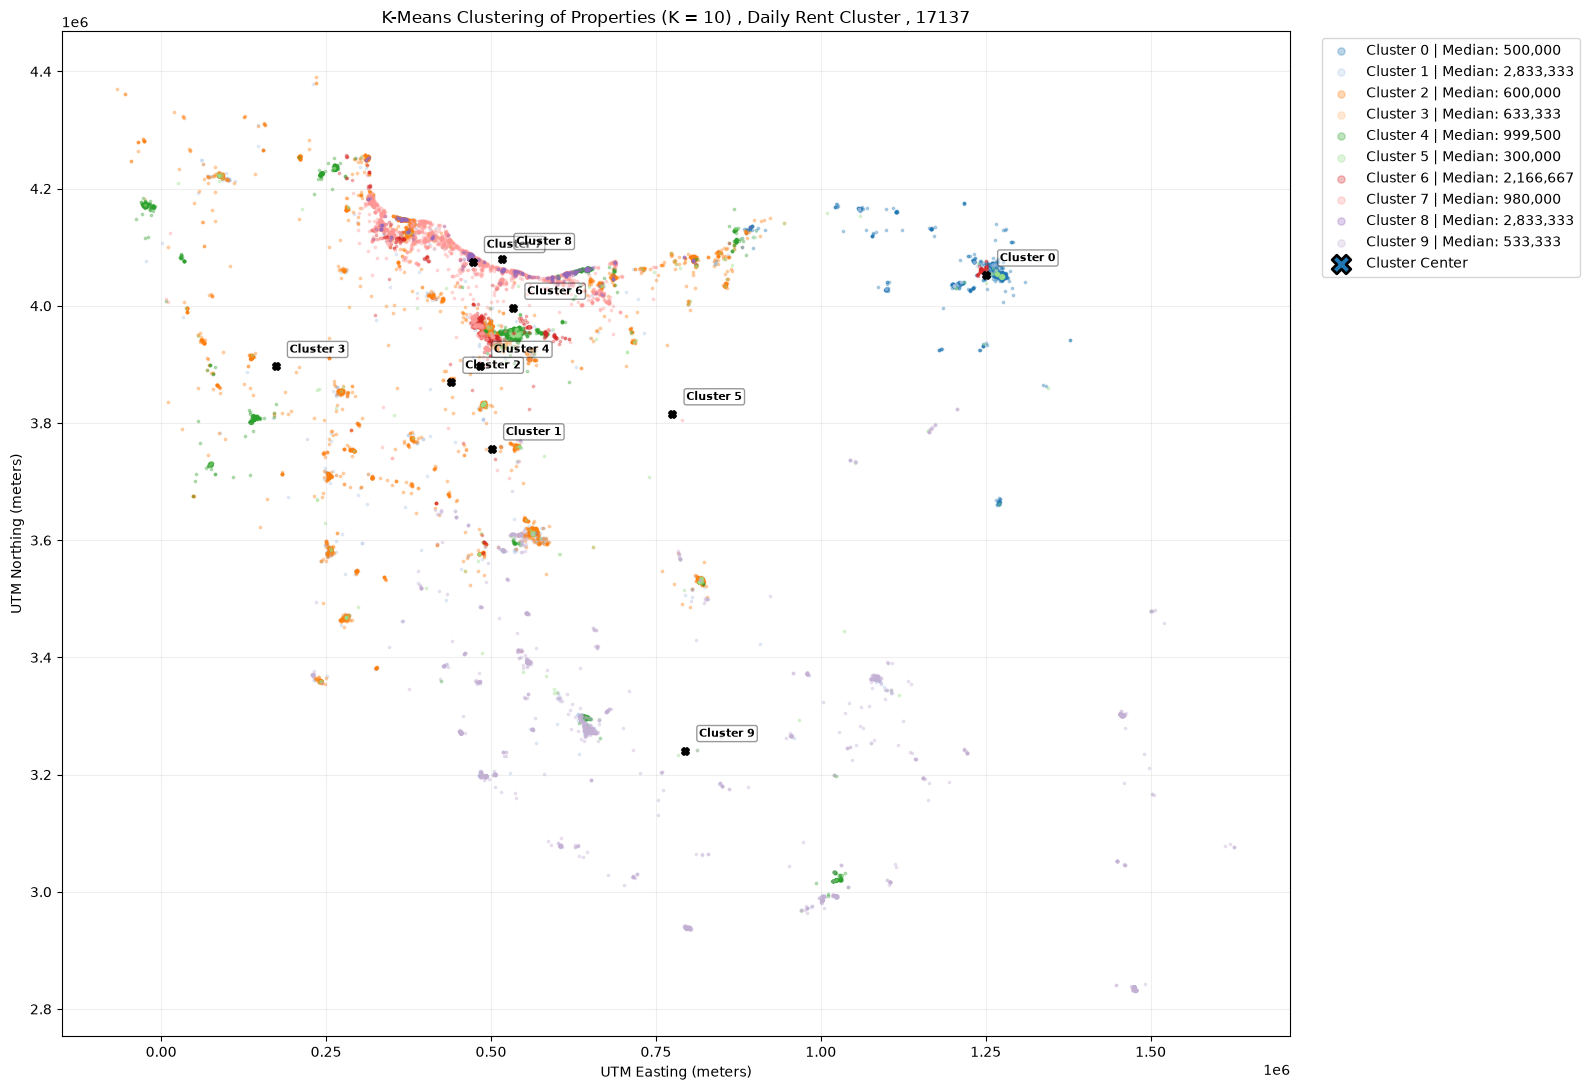

In [28]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'daily_rent'
]
plot_cluster(df_daily_price , 'Daily Rent Cluster' , list_f , 10 , 10, wcss_en = False , plot_en = True , silhou_en= False , price_base='daily_rent')


# part 2 

In [ ]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'price_value'
]


wccs = []

for i in range(1 , 21):
    ws = plot_cluster(df_sale_price , 'Sale Cluster' , list_f , i , 10 , wcss_en = True , plot_en = False , silhou_en= False , price_base='price_value')
    wccs.append(ws)

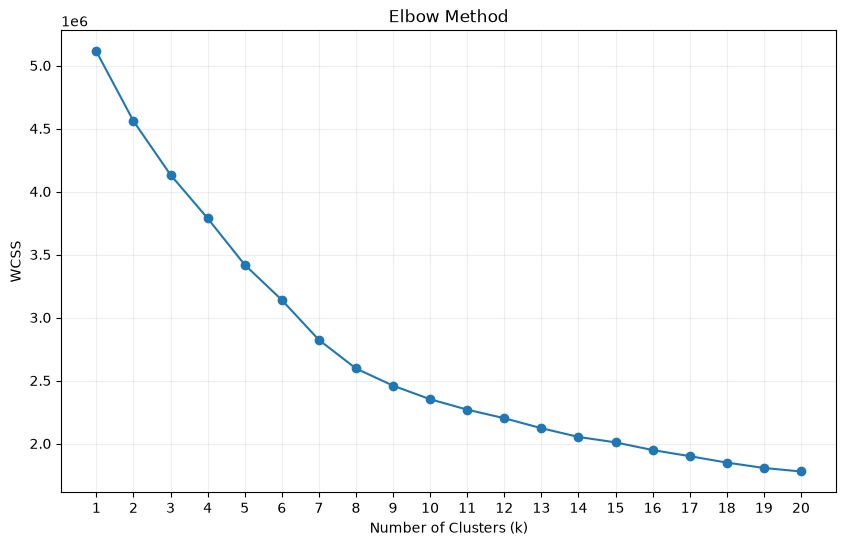

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21) , wccs , marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1, 21))
plt.grid(alpha=0.2)
plt.show()

In [37]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'price_value',  
]


silhou = []

for i in range(1 , 21):
    ws = plot_cluster(df_sale_price , 'Sale Cluster' , list_f , i , 10 , wcss_en = False , plot_en = False , silhou_en=True)
    silhou.append(ws)

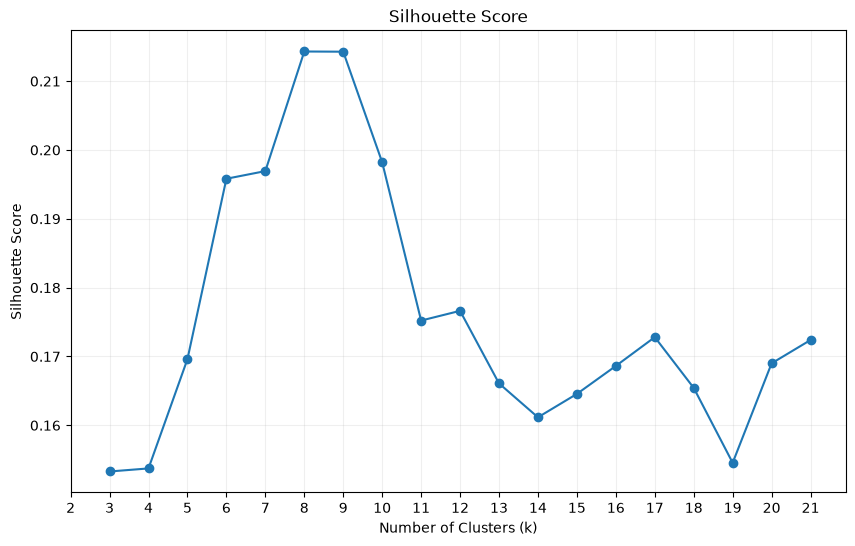

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(range(2, 22), silhou, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(range(2, 22))
plt.grid(alpha=0.2)

plt.show()

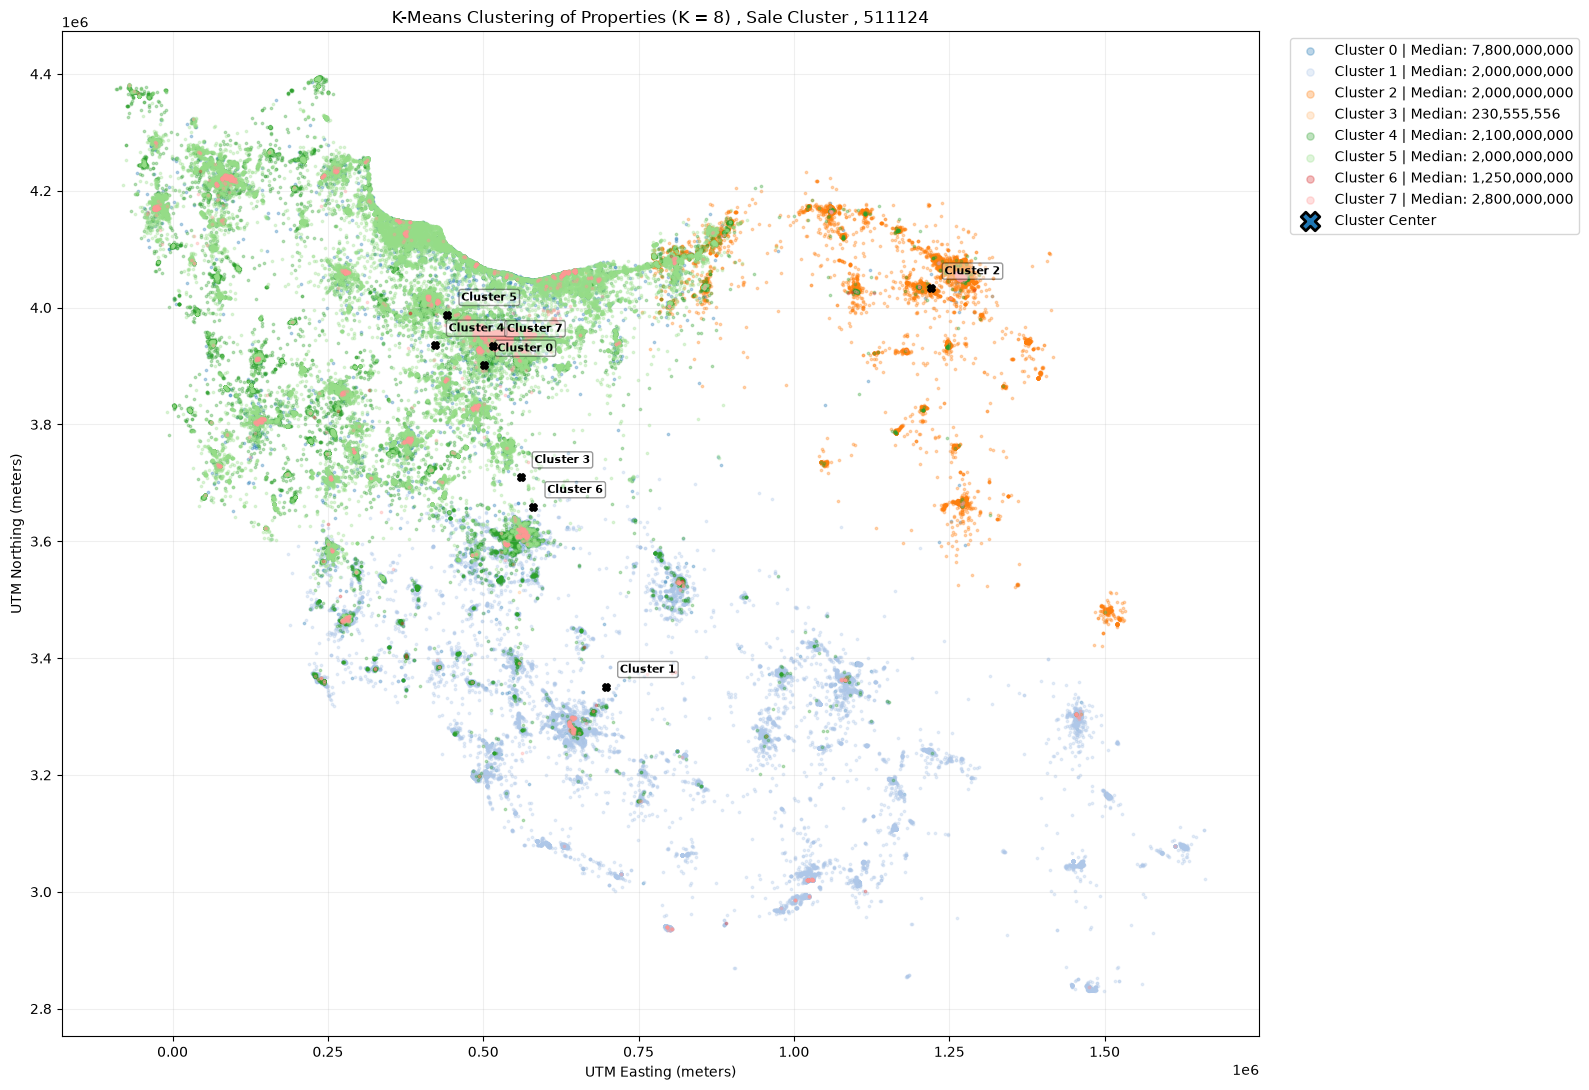

In [134]:
list_f = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'price_value'
]


plot_cluster(df_sale_price , 'Sale Cluster' , list_f , 8 , 10, wcss_en = False , plot_en = True , silhou_en= False , price_base='price_value')


# part 3 

In [153]:
df_dbscan = df_sale_price.sample(n=10000 , random_state=42).copy()


Q1 = df_dbscan['price_value'].quantile(0.25)
Q3 = df_dbscan['price_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_dbscan = df_dbscan[(df_dbscan['price_value'] >= lower_bound) & (df_dbscan['price_value'] <= upper_bound)].copy()


transformer = Transformer.from_crs('EPSG:4326' , 'EPSG:32639' , always_xy=True)
df_dbscan['utm_easting'], df_dbscan['utm_northing'] = transformer.transform(df_dbscan['location_longitude'].values , df_dbscan['location_latitude'].values)
df_dbscan = df_dbscan.dropna(subset=['utm_easting', 'utm_northing', 'comparable_price']).copy()

features = ['utm_easting' , 'utm_northing' , 'price_value']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dbscan[features])


In [155]:
for eps in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    for min_samples in [5, 10, 20, 30, 50]:
        dbscan = DBSCAN(eps=eps , min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        print(f"eps={eps} , "f"min_samples={min_samples} , "f"clusters={n_clusters}")

eps=0.2 , min_samples=5 , clusters=51
eps=0.2 , min_samples=10 , clusters=24
eps=0.2 , min_samples=20 , clusters=18
eps=0.2 , min_samples=30 , clusters=11
eps=0.2 , min_samples=50 , clusters=7
eps=0.3 , min_samples=5 , clusters=19
eps=0.3 , min_samples=10 , clusters=12
eps=0.3 , min_samples=20 , clusters=8
eps=0.3 , min_samples=30 , clusters=8
eps=0.3 , min_samples=50 , clusters=7
eps=0.4 , min_samples=5 , clusters=12
eps=0.4 , min_samples=10 , clusters=10
eps=0.4 , min_samples=20 , clusters=7
eps=0.4 , min_samples=30 , clusters=6
eps=0.4 , min_samples=50 , clusters=3
eps=0.5 , min_samples=5 , clusters=5
eps=0.5 , min_samples=10 , clusters=3
eps=0.5 , min_samples=20 , clusters=4
eps=0.5 , min_samples=30 , clusters=5
eps=0.5 , min_samples=50 , clusters=4
eps=0.6 , min_samples=5 , clusters=3
eps=0.6 , min_samples=10 , clusters=4
eps=0.6 , min_samples=20 , clusters=2
eps=0.6 , min_samples=30 , clusters=3
eps=0.6 , min_samples=50 , clusters=2
eps=0.7 , min_samples=5 , clusters=1
eps=0.7 , 

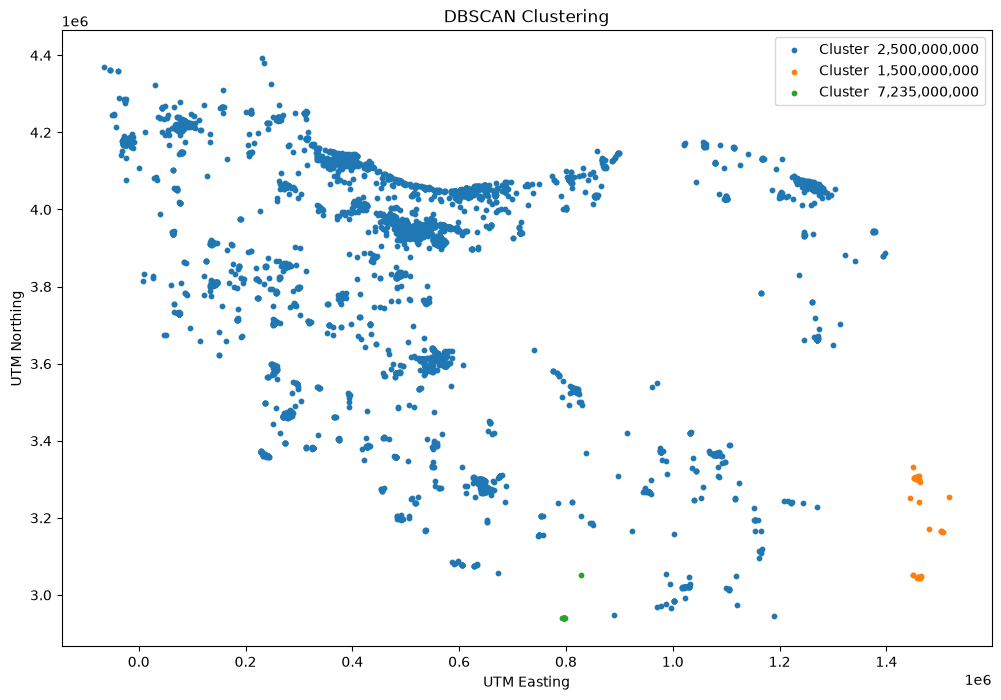

In [160]:
dbscan = DBSCAN(eps=0.5 , min_samples= 10 , n_jobs=-1)
df_dbscan['cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))

clusters = sorted(df_dbscan['cluster'].unique())

for cluster in clusters:
    data = df_dbscan[df_dbscan['cluster'] == cluster]

    if cluster == -1:
        #plt.scatter(data['utm_easting'] , data['utm_northing'] , s=10 , label='Noise')
        pass
    else:
        median_price = data['price_value'].median()
        plt.scatter(data['utm_easting'] , data['utm_northing'] , s=10 , label=f'Cluster  {median_price:,.0f}')

plt.xlabel('UTM Easting')
plt.ylabel('UTM Northing')
plt.title('DBSCAN Clustering')
plt.legend()
plt.show()